In [86]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 
import time as t 
import random as rnd

seed = 42
rnd.seed(seed)
np.random.seed(seed)

print(f"Imported at: {t.ctime()}")

Imported at: Sun Mar 15 14:20:57 2026


In [87]:
results = "gat_results_heldout.csv"
df_results = pd.read_csv(results)
print(df_results.head())

names = ["0%", "33%", "67%"]

"""
Columns are: ["Dataset","Fold","Val_RMSE", "Val_MAE", "Val_Pearson", "Holdout_MSE", "Holdout_RMSE", "Holdout_MAE", "Holdout_R2", "Holdout_Rho", "Holdout_Pearson"]
What presentage synthetic they are from is in:

Dataset: "0%", "33%", "67%"
"""

zero_percent = df_results[df_results["Dataset"] == "0%"]
thirtythree_percent = df_results[df_results["Dataset"] == "33%"]
sixtyseven_percent = df_results[df_results["Dataset"] == "67%"]


  Dataset  Fold             Checkpoint  Val_RMSE   Val_MAE  Val_Pearson  \
0      0%     0  best_model_fold_0.pth  0.743166  0.560236     0.870015   
1      0%     1  best_model_fold_1.pth  0.697843  0.545803     0.817961   
2      0%     2  best_model_fold_2.pth  0.763906  0.587726     0.813822   
3      0%     3  best_model_fold_3.pth  0.816604  0.624938     0.814922   
4      0%     4  best_model_fold_4.pth  0.848269  0.632572     0.807615   

   Holdout_MSE  Holdout_RMSE  Holdout_MAE  Holdout_R2  Holdout_Rho  \
0     0.528507      0.726985     0.579224    0.507314     0.651979   
1     0.419356      0.647577     0.519434    0.609067     0.741293   
2     0.464030      0.681198     0.552835    0.567421     0.714243   
3     0.416004      0.644984     0.511024    0.612192     0.721459   
4     0.492463      0.701757     0.560137    0.540916     0.676155   

   Holdout_Pearson  
0         0.728625  
1         0.784761  
2         0.767573  
3         0.787885  
4         0.737061  


Plotting dataset from folder=./0%, file=MPNN_losses_0%.txt


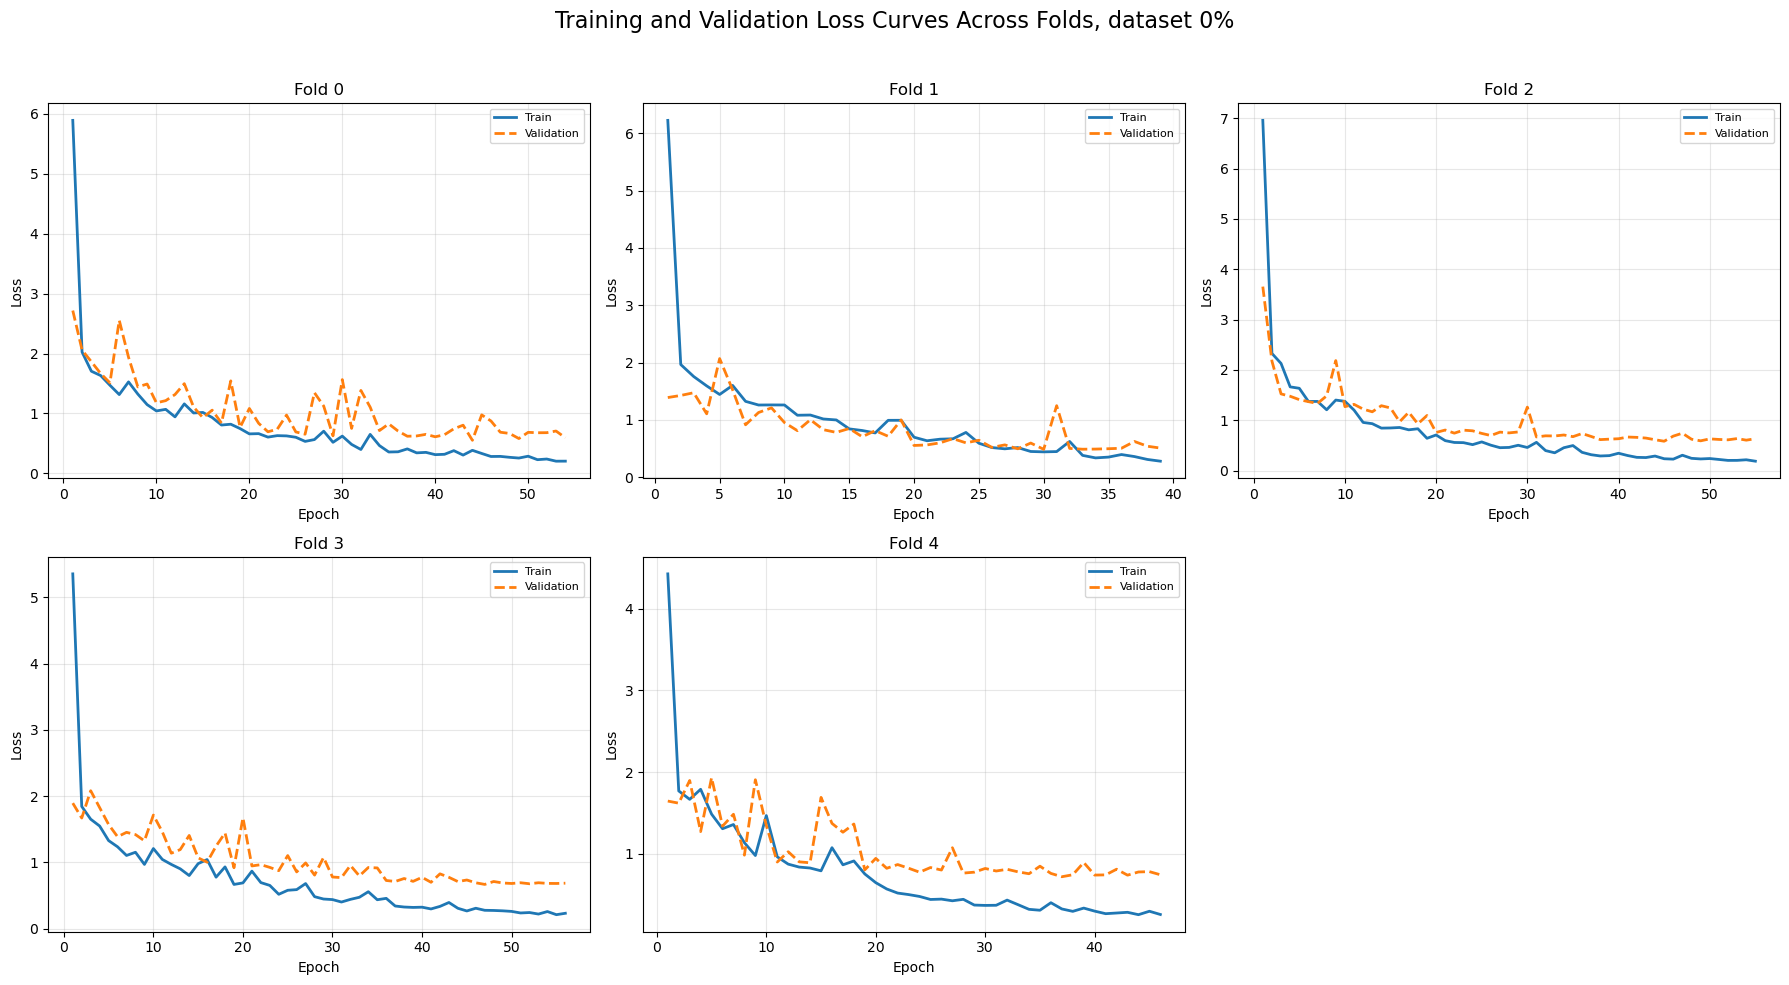

Plotting dataset from folder=./33%, file=MPNN_losses_33%.txt


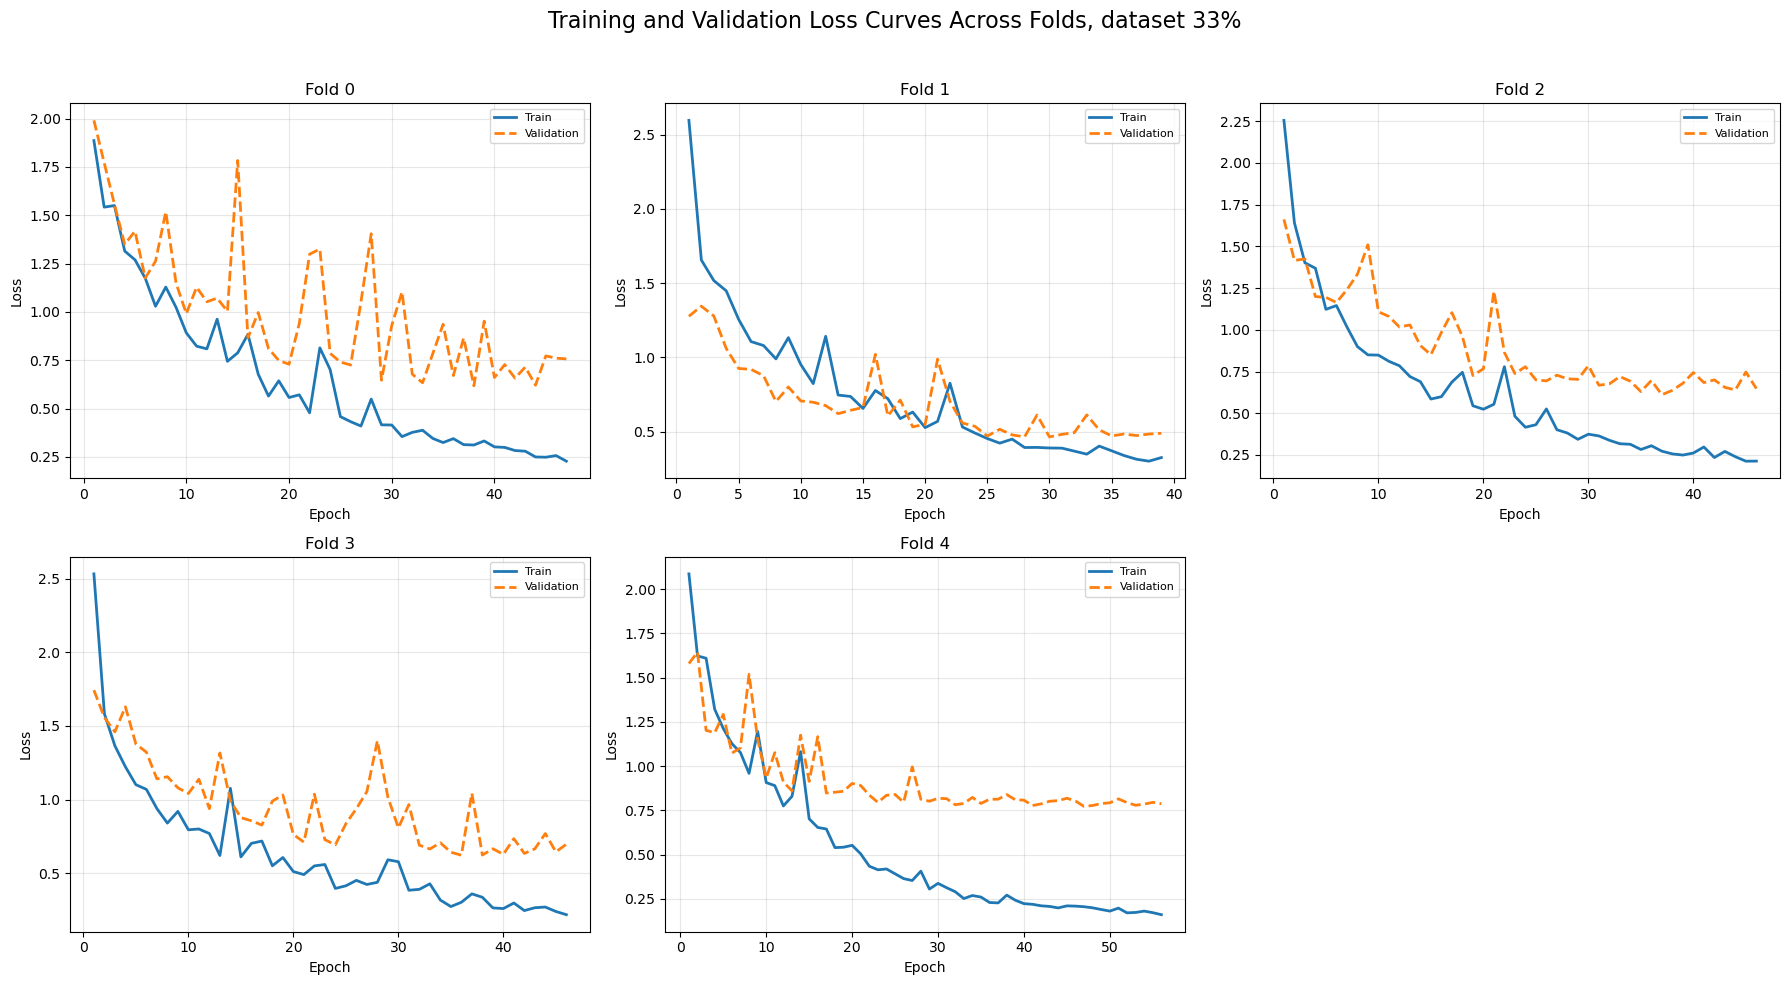

Plotting dataset from folder=./67%, file=MPNN_losses_67%.txt


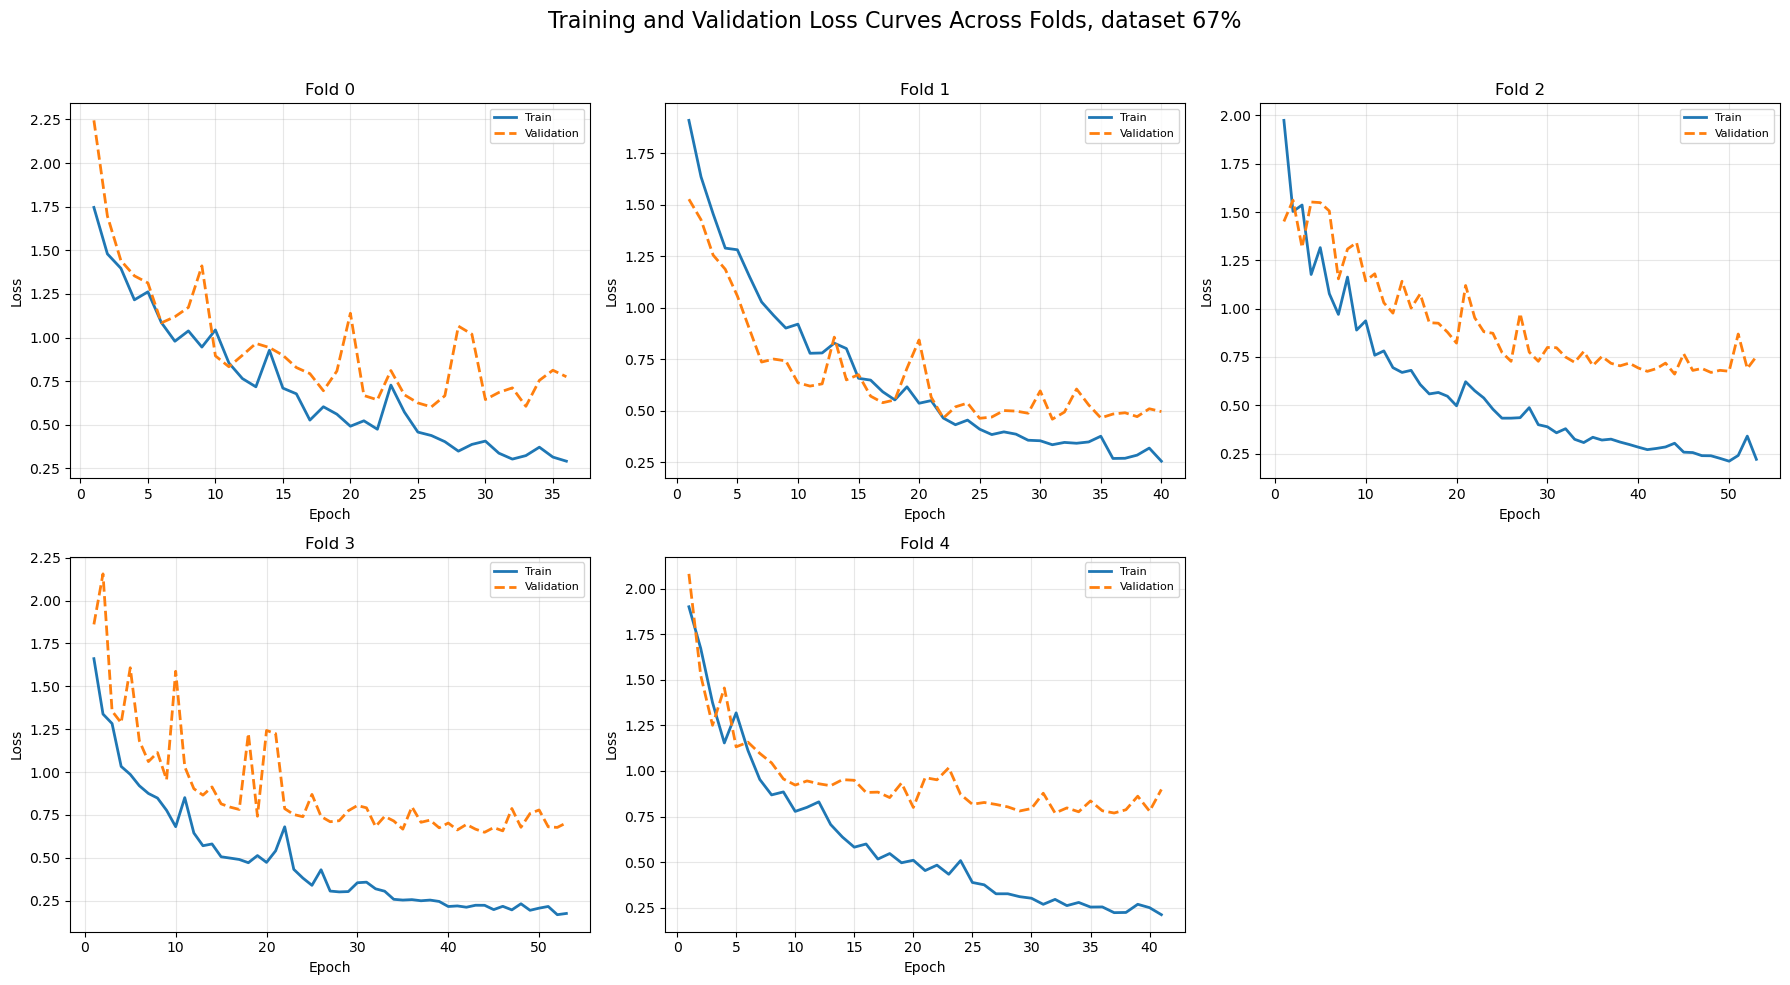

In [88]:
import os
import io
import re
import pandas as pd
import matplotlib.pyplot as plt


folders = ["./0%", "./33%", "./67%"]
path_in_folder = ["MPNN_losses_0%.txt", "MPNN_losses_33%.txt", "MPNN_losses_67%.txt"]


def load_fold_loss_file(file_path: str) -> dict[int, pd.DataFrame]:
    """
    Read a custom loss file with sections like:

    fold_0:
       train      val  monitor       lr
    5.560307 2.158475 1.469175 0.001000
    ...

    fold_1:
       train      val  monitor       lr
    ...

    Returns:
        dict mapping fold index -> DataFrame with columns:
        ['train', 'val', 'monitor', 'lr']
    """
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Split on lines like "fold_0:", "fold_1:", ...
    parts = re.split(r"(fold_\d+:)\s*", text)

    fold_data = {}

    # parts looks like:
    # [text_before, 'fold_0:', content0, 'fold_1:', content1, ...]
    for i in range(1, len(parts), 2):
        fold_header = parts[i].strip()
        fold_block = parts[i + 1].strip()

        match = re.match(r"fold_(\d+):", fold_header)
        if not match:
            continue

        fold_idx = int(match.group(1))

        # Remove empty lines inside block
        lines = [line.rstrip() for line in fold_block.splitlines() if line.strip()]
        if not lines:
            continue

        # Rebuild mini-table text for pandas
        block_text = "\n".join(lines)

        # Parse whitespace-separated mini table
        df = pd.read_csv(io.StringIO(block_text), sep=r"\s+")


        fold_data[fold_idx] = df

    return fold_data


def plot_loss_curves_subplots(
    folder: str,
    filename: str,
    max_folds: int = 5,
    figsize: tuple[int, int] = (18, 10),
):
    """
    Plot one dataset in one large figure with 5 smaller subplots,
    one subplot per fold.

    Parameters
    ----------
    folder : str
        Folder containing the loss file, for example "./0%".
    filename : str
        Name of the loss file, for example "MPNN_losses_0%.txt".
    max_folds : int
        Number of folds to plot.
    figsize : tuple[int, int]
        Figure size.
    """
    file_path = os.path.join(folder, filename)

    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found. Skipping this dataset.")
        return

    try:
        fold_data = load_fold_loss_file(file_path)
    except Exception as e:
        print(f"Warning: failed to parse {file_path}: {e}")
        return

    if not fold_data:
        print(f"No valid fold data found in {file_path}.")
        return

    dataset_label = os.path.basename(os.path.normpath(folder))

    # Create 2x3 grid, hide the last subplot if only 5 folds
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    for fold_idx in range(max_folds):
        ax = axes[fold_idx]

        if fold_idx not in fold_data:
            ax.set_title(f"Fold {fold_idx} (missing)")
            ax.axis("off")
            continue

        df = fold_data[fold_idx]
        epochs = range(1, len(df) + 1)

        ax.plot(epochs, df["train"], label="Train", linewidth=2)
        ax.plot(epochs, df["val"], label="Validation", linestyle="--", linewidth=2)

        ax.set_title(f"Fold {fold_idx}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # Hide unused axes
    for i in range(max_folds, len(axes)):
        axes[i].axis("off")

    fig.suptitle(
        f"Training and Validation Loss Curves Across Folds, dataset {dataset_label}",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def iterate_datasets(
    folders: list[str],
    filenames: list[str],
    max_folds: int = 5,
    figsize: tuple[int, int] = (18, 10),
):
    """
    Iterate over datasets and plot one figure per dataset.

    Parameters
    ----------
    folders : list[str]
        Dataset folders, for example ["./0%", "./33%", "./67%"].
    filenames : list[str]
        Matching filenames for each folder.
    max_folds : int
        Number of folds to plot.
    figsize : tuple[int, int]
        Figure size.
    """
    if len(folders) != len(filenames):
        raise ValueError("folders and filenames must have the same length.")

    for folder, filename in zip(folders, filenames):
        print(f"Plotting dataset from folder={folder}, file={filename}")
        plot_loss_curves_subplots(
            folder=folder,
            filename=filename,
            max_folds=max_folds,
            figsize=figsize,
        )


iterate_datasets(folders, path_in_folder)

  Dataset  Fold             Checkpoint  Val_RMSE   Val_MAE  Val_Pearson  \
0      0%     0  best_model_fold_0.pth  0.743166  0.560236     0.870015   
1      0%     1  best_model_fold_1.pth  0.697843  0.545803     0.817961   
2      0%     2  best_model_fold_2.pth  0.763906  0.587726     0.813822   
3      0%     3  best_model_fold_3.pth  0.816604  0.624938     0.814922   
4      0%     4  best_model_fold_4.pth  0.848269  0.632572     0.807615   

   Holdout_MSE  Holdout_RMSE  Holdout_MAE  Holdout_R2  Holdout_Rho  \
0     0.528507      0.726985     0.579224    0.507314     0.651979   
1     0.419356      0.647577     0.519434    0.609067     0.741293   
2     0.464030      0.681198     0.552835    0.567421     0.714243   
3     0.416004      0.644984     0.511024    0.612192     0.721459   
4     0.492463      0.701757     0.560137    0.540916     0.676155   

   Holdout_Pearson  
0         0.728625  
1         0.784761  
2         0.767573  
3         0.787885  
4         0.737061  
['

C:\Users\kjo02\AppData\Local\Temp\ipykernel_21528\3192394916.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_21528\3192394916.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_21528\3192394916.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\kjo02\AppData\Local\Temp\ipykernel_21528\3192394916.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

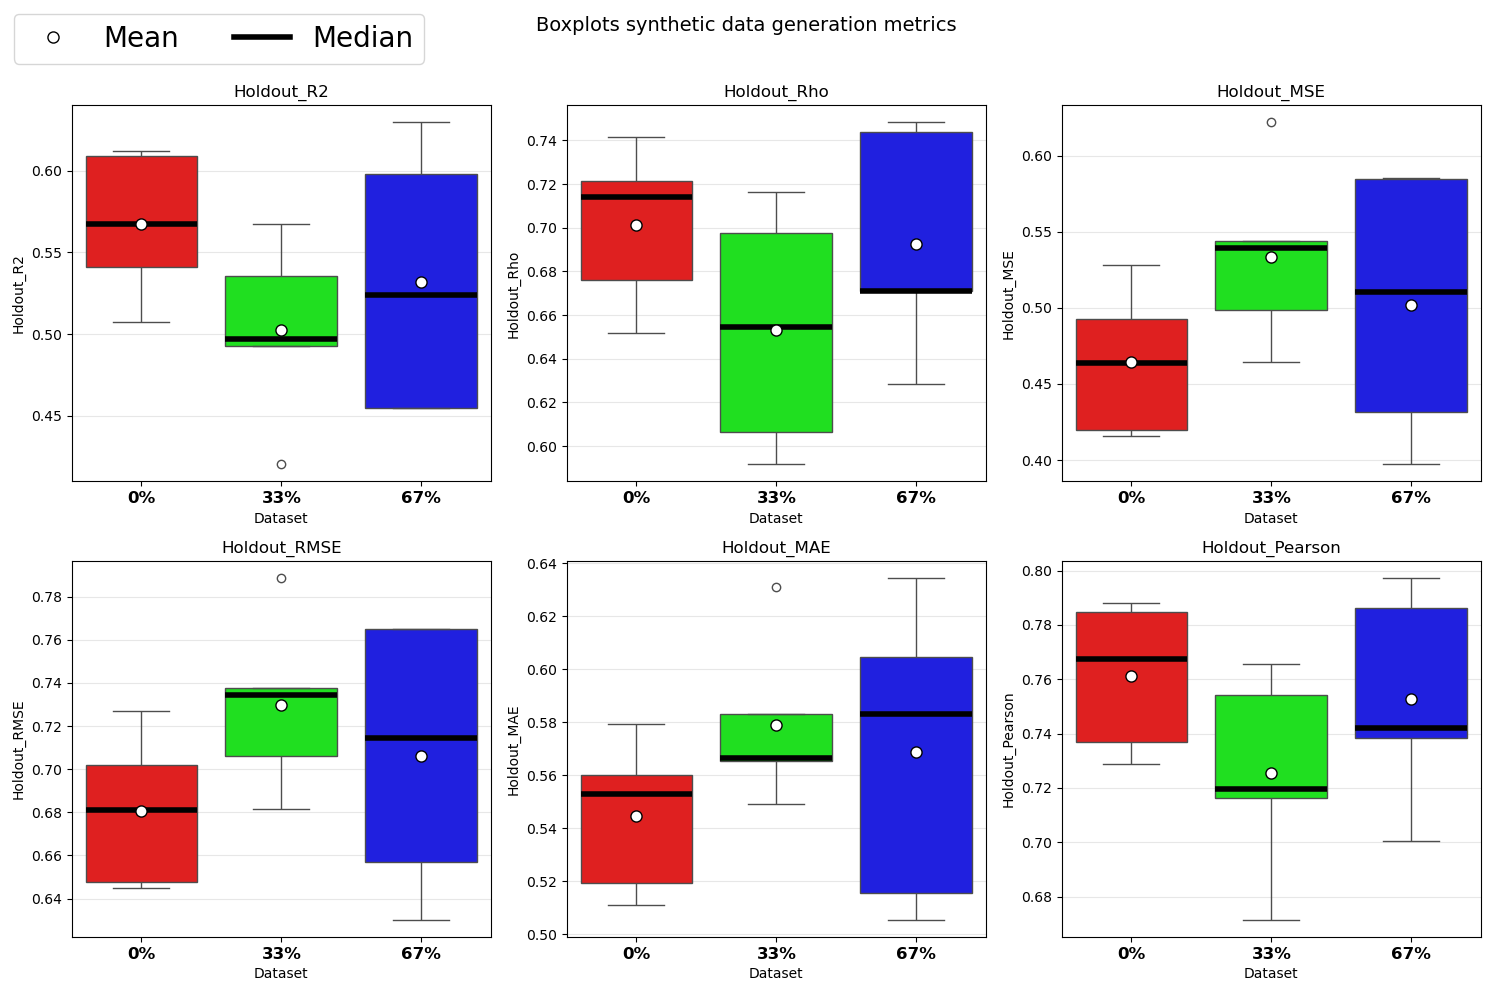

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


results = "gat_results_heldout.csv"
df_results = pd.read_csv(results)

print(df_results.head())
print(df_results.columns.tolist())

names = ["0%", "33%", "67%"]


def simple_metric_boxplots(df: pd.DataFrame, metrics: str | list[str], title: str = "Boxplots"):
    if isinstance(metrics, str):
        metrics = [metrics]

    amount = len(metrics)
    n_per_row = min(3, amount)  # max 3 plots per row for better aesthetics
    rows = (amount + n_per_row - 1) // n_per_row  # calculate number of rows needed
    fig, axs = plt.subplots(rows, n_per_row, figsize=(5 * n_per_row, 5 * rows)) # Adjust figure size based on number of plots

    if len(metrics) == 1:
        axs = [axs]
    


    axs = np.atleast_1d(axs).flatten()
    plot_df = df[df["Dataset"].isin(names)].copy()

    colors = ['#FF0000', '#00FF00', '#0000FF']  # Red, Green, Blue for the three datasets
    #colors = sns.color_palette("tab10", n_colors=len(metrics))  # Seaborn Set2 palette for better aesthetics
    idx = 0
    for ax, metric in zip(axs, metrics):
        if metric not in plot_df.columns:
            ax.set_visible(False)
            print(f"Warning: metric '{metric}' not found in dataframe columns.")
            continue

        
        mean_handle = Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='white',
            markeredgecolor='black',
            markersize=8,
            label='Mean'
        )

        median_handle = Line2D(
            [0], [0],
            color='black',
            linewidth=4,
            label='Median'
        )
        sns.boxplot(
            x="Dataset",
            y=metric,
            data=plot_df,
            order=names,
            ax=ax,
            showfliers=True,
            palette=colors,
            showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
            medianprops={
                "linewidth": 4,
                "color": "black"
            }
        )
        
        ax.set_title(metric)
        ax.set_xlabel("Dataset")
        ax.set_ylabel(metric)
        ax.grid(axis="y", alpha=0.3)
        for label in ax.get_xticklabels():
            label.set_fontsize(12)
            label.set_fontweight('bold')
    # Hide any unused subplot axes
    for ax in axs[len(metrics):]:
        ax.set_visible(False)
    fig.legend(
        handles=[mean_handle, median_handle],
        loc='upper left',
        ncol=3,
        fontsize=20,
        frameon=True
    )
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=300)  # Save the figure as a high-resolution PNG file
    plt.show()


"""
Columns are: ["Dataset","Fold","Val_RMSE", "Val_MAE", "Val_Pearson", "Holdout_MSE", "Holdout_RMSE", "Holdout_MAE", "Holdout_R2", "Holdout_Rho", "Holdout_Pearson"]
What presentage synthetic they are from is in:

Dataset: "0%", "33%", "67%"
"""

simple_metric_boxplots(
    df_results,
    ["Holdout_R2", "Holdout_Rho", "Holdout_MSE","Holdout_RMSE", "Holdout_MAE", "Holdout_Pearson"],
    title="Boxplots synthetic data generation metrics"
)


Loaded prediction file
Shape: (3000, 9)
Unique datasets: ['0%', '33%', '67%']
Unique folds:    [0, 1, 2, 3, 4]
Unique molecules: 200
Skipped saving row_summary.csv (SAVE_OPTIONS['row_summary_csv'] = False)

Row-level summary:
 Dataset  n_rows  n_unique_molecules  mean_abs_error     rmse
     0%    1000                 200        0.544531 0.681228
    33%    1000                 200        0.579028 0.730533
    67%    1000                 200        0.568606 0.708417
Saved: pretrain\fold_summary.csv

Fold-level summary:
 Dataset  Fold  n_rows  n_unique_molecules  mean_abs_error     rmse  mean_residual
     0%     0     200                 200        0.579224 0.726985       0.111587
     0%     1     200                 200        0.519434 0.647577       0.027483
     0%     2     200                 200        0.552835 0.681198      -0.094851
     0%     3     200                 200        0.511024 0.644984       0.018256
     0%     4     200                 200        0.560137 0.7017

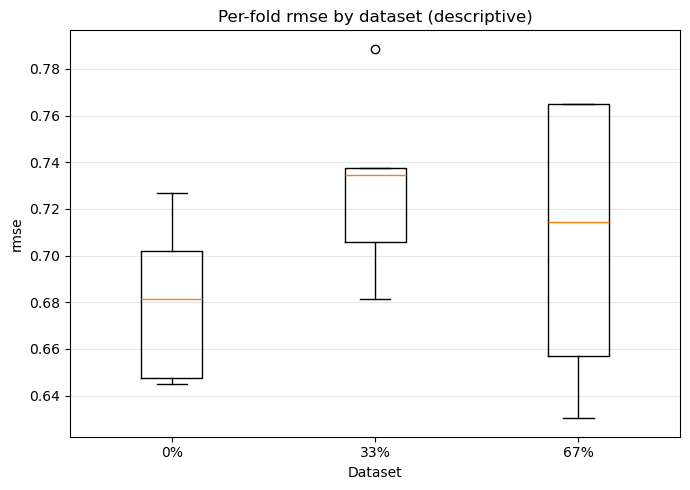

Skipped saving fold_boxplot_mean_abs_error.png (SAVE_OPTIONS['fold_boxplots'] = False)


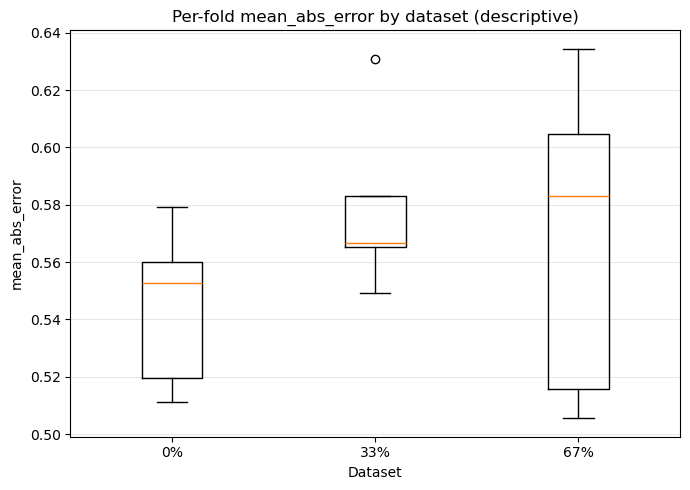

Skipped saving fold_boxplot_mean_residual.png (SAVE_OPTIONS['fold_boxplots'] = False)


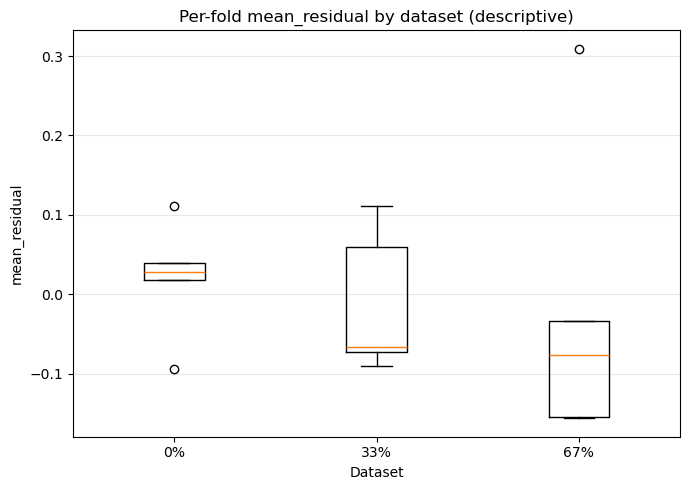

Skipped saving molecule_boxplot_mean_abs_error.png (SAVE_OPTIONS['molecule_boxplots'] = False)


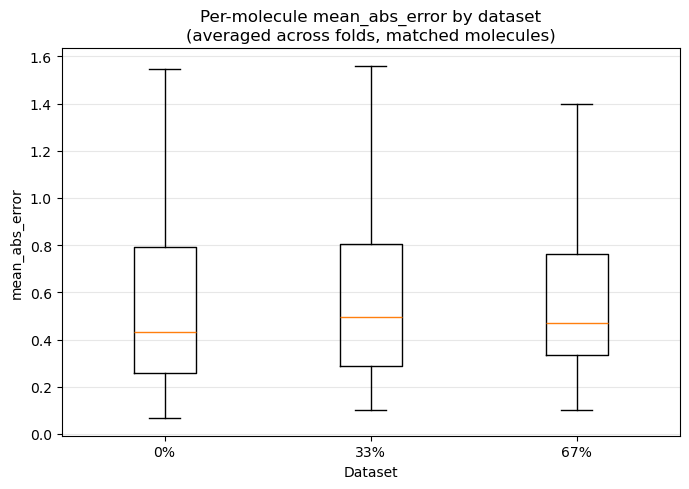

Skipped saving molecule_boxplot_rmse.png (SAVE_OPTIONS['molecule_boxplots'] = False)


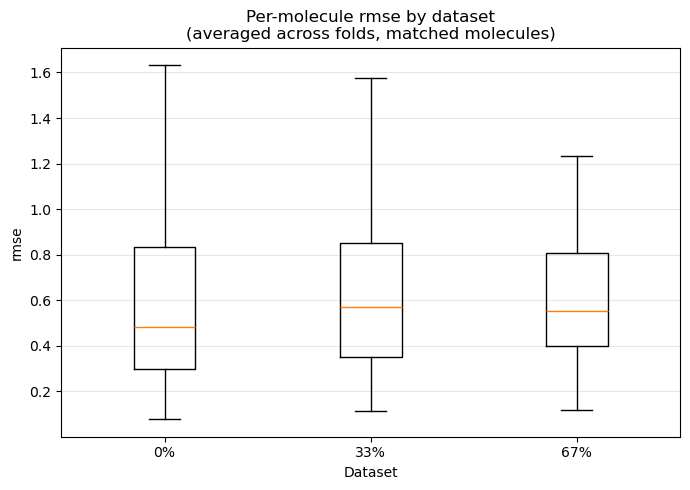

Skipped saving paired_delta_mean_abs_error.png (SAVE_OPTIONS['paired_delta_boxplots'] = False)


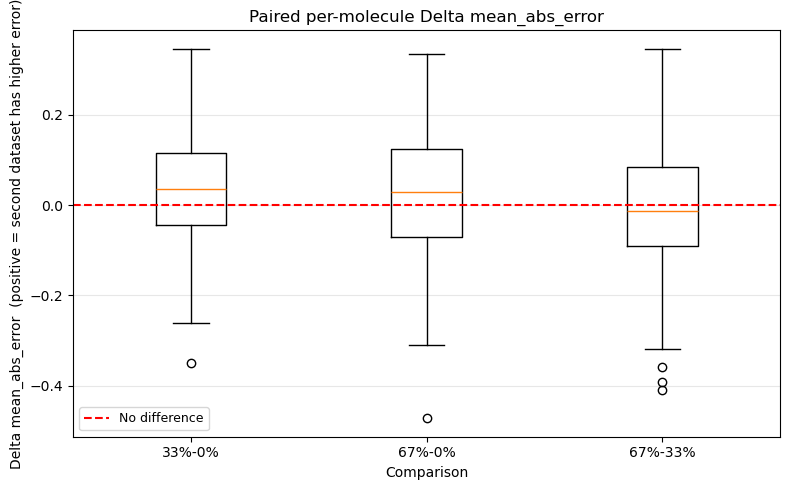

Skipped saving paired_delta_rmse.png (SAVE_OPTIONS['paired_delta_boxplots'] = False)


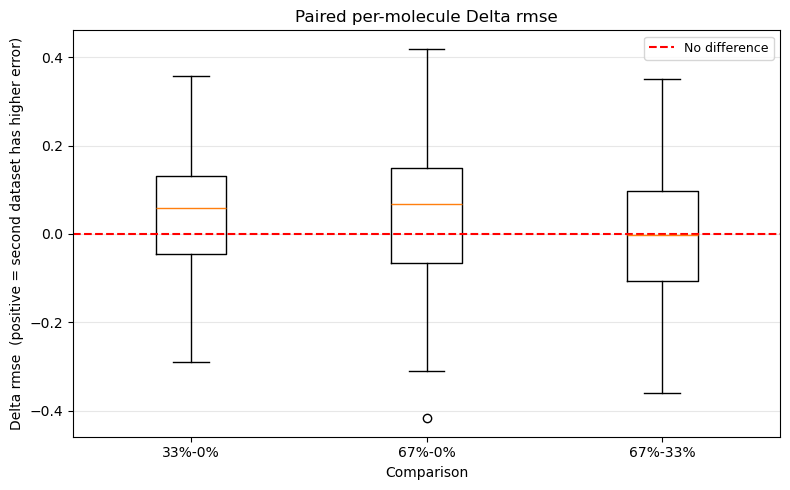

Skipped saving slope_plot_mean_abs_error.png (SAVE_OPTIONS['slope_plots'] = False)


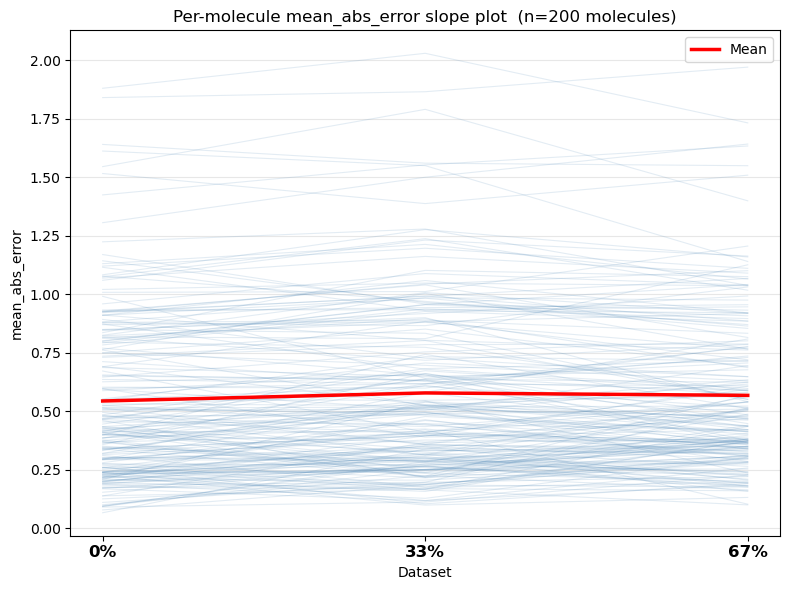

Skipped saving slope_plot_rmse.png (SAVE_OPTIONS['slope_plots'] = False)


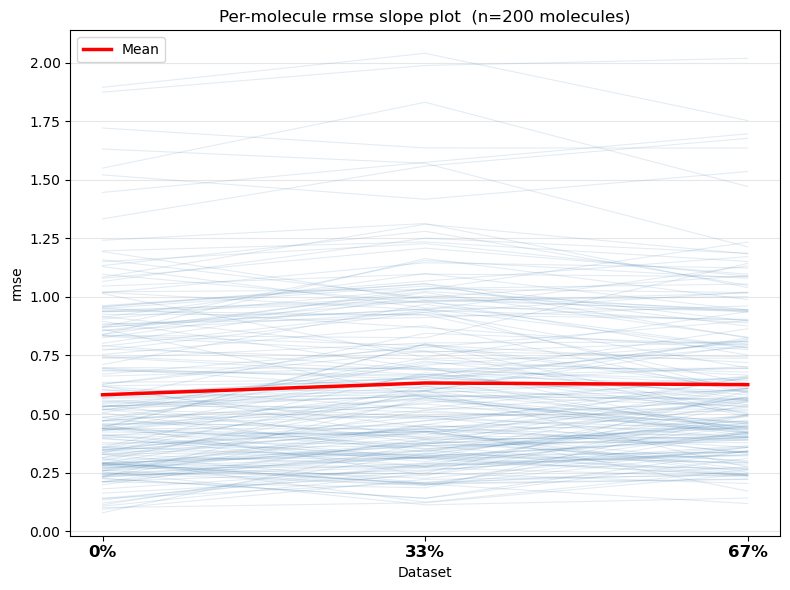

FileNotFoundError: [Errno 2] No such file or directory: 'pretrain\\molecule_level_dataset.csv'

In [90]:
# ==============================================================================
# CHANGELOG
# ==============================================================================
# v2.1
# - Added central SAVE_OPTIONS config so you can toggle saved outputs on/off.
# - All CSV saving now goes through save_dataframe(..., save_key=...).
# - All figure saving now goes through save_plot(..., save_key=...).
# - Added separate save toggles for:
#     * summaries
#     * molecule-level tables
#     * statistical tests
#     * paired/improvement tables
#     * run config
#     * block 2 outputs
#     * each plot family
# - Kept the overall structure and comments.
# ==============================================================================


# ==============================================================================
# BLOCK 1: WITHIN-PRETRAIN ANALYSIS
# ==============================================================================

import os
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon


# ==============================================================================
# Configuration
# ==============================================================================

PREDICTIONS_CSV = "GAT_predictions_heldout_set.csv"
DATASET_ORDER = ["0%", "33%", "67%"]
OUTPUT_DIR = "pretrain"
MOLECULE_LEVEL_METRICS = ["mean_abs_error", "rmse"]

# ------------------------------------------------------------------------------
# Save toggles
# Set any of these to True/False depending on what you want to save.
# These only control saving to disk. The analysis and printed output still run.
# ------------------------------------------------------------------------------
SAVE_OPTIONS = {
    # Block 1 tables
    "row_summary_csv": False,
    "fold_summary_csv": True,
    "molecule_level_dataset_csv": False,
    "molecule_summary_csv": False,
    "statistical_tests_csv": True,
    "rmse_improvement_csv": False,
    "paired_rmse_differences_csv": False,
    "paired_mae_differences_csv": False,
    "run_config_csv": True,

    # Block 1 plots
    "fold_boxplots": False,
    "molecule_boxplots": False,
    "paired_delta_boxplots": False,
    "slope_plots": False,

    # Block 2 tables
    "pretrain_vs_no_pretrain_per_ratio_csv": False,
    "pretrain_vs_no_pretrain_aggregated_csv": False,
    "pretrain_vs_no_pretrain_diff_tables": False,
}


# ==============================================================================
# Utility
# ==============================================================================

def holm_correction(p_values: list[float]) -> list[float]:
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    sorted_p = p_values[order]
    adjusted = np.empty(n, dtype=float)
    running_max = 0.0

    for i, p in enumerate(sorted_p):
        adjusted_value = min((n - i) * p, 1.0)
        running_max = max(running_max, adjusted_value)
        adjusted[i] = running_max

    corrected = np.empty(n, dtype=float)
    corrected[order] = adjusted
    return corrected.tolist()


def should_save(save_key: str | None) -> bool:
    """Return True if a given save category is enabled."""
    if save_key is None:
        return True
    return SAVE_OPTIONS.get(save_key, True)


def save_dataframe(
    df: pd.DataFrame,
    output_dir: str,
    filename: str,
    save_key: str | None = None,
) -> None:
    """Save a dataframe only if the corresponding save toggle is enabled."""
    if not should_save(save_key):
        print(f"Skipped saving {filename} (SAVE_OPTIONS['{save_key}'] = False)")
        return

    path = os.path.join(output_dir, filename)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def save_plot(
    fig,
    output_dir: str,
    filename: str,
    save_key: str | None = None,
) -> None:
    """Save a matplotlib figure only if the corresponding save toggle is enabled."""
    if not should_save(save_key):
        print(f"Skipped saving {filename} (SAVE_OPTIONS['{save_key}'] = False)")
        return

    path = os.path.join(output_dir, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


# ==============================================================================
# Data loading and feature engineering
# ==============================================================================

def load_and_prepare_predictions(predictions_csv: str) -> pd.DataFrame:
    df = pd.read_csv(predictions_csv)

    required_cols = ["Dataset", "Fold", "smiles", "True_pIC50", "Pred_pIC50"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["Fold"] = pd.to_numeric(df["Fold"], errors="raise")
    df["residual"] = df["Pred_pIC50"] - df["True_pIC50"]
    df["abs_error"] = df["residual"].abs()
    df["squared_error"] = df["residual"] ** 2
    return df


# ==============================================================================
# Summaries
# ==============================================================================

def summarize_row_level(df: pd.DataFrame) -> pd.DataFrame:
    """One row per dataset, descriptive only."""
    return (
        df.groupby("Dataset", as_index=False)
        .agg(
            n_rows=("smiles", "size"),
            n_unique_molecules=("smiles", "nunique"),
            mean_abs_error=("abs_error", "mean"),
            rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
        )
    )


def summarize_fold_level(df: pd.DataFrame) -> pd.DataFrame:
    """One row per (Dataset, Fold), used for fold-level descriptive boxplots."""
    return (
        df.groupby(["Dataset", "Fold"], as_index=False)
        .agg(
            n_rows=("smiles", "size"),
            n_unique_molecules=("smiles", "nunique"),
            mean_abs_error=("abs_error", "mean"),
            rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
            mean_residual=("residual", "mean"),
        )
    )


def aggregate_per_molecule_per_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Average across folds, one row per (smiles, Dataset). Fair unit for tests."""
    return (
        df.groupby(["smiles", "Dataset"], as_index=False)
        .agg(
            True_pIC50=("True_pIC50", "first"),
            mean_abs_error=("abs_error", "mean"),
            rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
        )
    )


def build_molecule_level_summary(mol_dataset: pd.DataFrame) -> pd.DataFrame:
    return (
        mol_dataset.groupby("Dataset", as_index=False)
        .agg(
            n_molecules=("smiles", "nunique"),
            mean_mae=("mean_abs_error", "mean"),
            median_mae=("mean_abs_error", "median"),
            mean_rmse=("rmse", "mean"),
            median_rmse=("rmse", "median"),
        )
    )


# ==============================================================================
# Statistical tests
# ==============================================================================

def run_friedman_and_wilcoxon(
    mol_dataset: pd.DataFrame,
    dataset_order: list[str],
    metrics: list[str],
) -> pd.DataFrame:
    """
    For each metric:
      1. Pivot to matched molecules x datasets (drops molecules missing any dataset).
      2. Friedman test across all three dataset conditions.
      3. Pairwise Wilcoxon signed-rank tests with Holm correction.
    """
    results = []

    for metric in metrics:
        pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
        pivot = pivot[dataset_order].dropna()

        if len(pivot) == 0:
            print(f"[warning] No matched molecules for metric: {metric}")
            continue

        friedman_stat, friedman_p = friedmanchisquare(
            *[pivot[d].to_numpy() for d in dataset_order]
        )

        metric_rows = []
        for da, db in combinations(dataset_order, 2):
            x = pivot[da].to_numpy()
            y = pivot[db].to_numpy()
            diff = x - y

            try:
                w_stat, w_p = wilcoxon(
                    x,
                    y,
                    alternative="two-sided",
                    zero_method="wilcox",
                    correction=False,
                    mode="auto",
                )
            except ValueError:
                w_stat, w_p = np.nan, np.nan

            metric_rows.append({
                "Metric": metric,
                "Dataset_A": da,
                "Dataset_B": db,
                "n_molecules": len(pivot),
                "Mean_A": np.mean(x),
                "Mean_B": np.mean(y),
                "Median_A": np.median(x),
                "Median_B": np.median(y),
                "Mean_diff_A_minus_B": np.mean(diff),
                "Median_diff_A_minus_B": np.median(diff),
                "Wilcoxon_stat": w_stat,
                "Wilcoxon_p": w_p,
                "Friedman_stat": friedman_stat,
                "Friedman_p": friedman_p,
            })

        corrected = holm_correction([r["Wilcoxon_p"] for r in metric_rows])
        for row, cp in zip(metric_rows, corrected):
            row["Wilcoxon_p_holm"] = cp
            results.append(row)

    return pd.DataFrame(results)


# ==============================================================================
# Improvement / paired difference tables
# ==============================================================================

def build_improvement_table(
    mol_dataset: pd.DataFrame,
    metric: str,
    dataset_order: list[str],
) -> pd.DataFrame:
    """Positive = lower error at the second dataset compared with the first."""
    pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
    pivot = pivot[dataset_order].dropna().copy()

    pivot["improvement_33_vs_0"] = pivot["0%"] - pivot["33%"]
    pivot["improvement_67_vs_0"] = pivot["0%"] - pivot["67%"]
    pivot["improvement_67_vs_33"] = pivot["33%"] - pivot["67%"]

    return pivot.reset_index()


def build_paired_diff_table(
    mol_dataset: pd.DataFrame,
    metric: str,
    dataset_order: list[str],
) -> pd.DataFrame:
    """Neutral difference columns, negative = second dataset has lower error."""
    pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
    pivot = pivot[dataset_order].dropna().copy()

    for i in range(len(dataset_order)):
        for j in range(i + 1, len(dataset_order)):
            da, db = dataset_order[i], dataset_order[j]
            pivot[f"{metric}_diff_{db}_minus_{da}"] = pivot[db] - pivot[da]

    return pivot.reset_index()


# ==============================================================================
# Plots
# ==============================================================================

def plot_fold_level_boxplots(fold_summary, dataset_order, metrics, output_dir):
    """Per-fold descriptive boxplots."""
    for metric in metrics:
        if metric not in fold_summary.columns:
            continue

        data = [
            fold_summary.loc[fold_summary["Dataset"] == d, metric].to_numpy()
            for d in dataset_order
        ]

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.boxplot(data, tick_labels=dataset_order, showfliers=True)
        ax.set_xlabel("Dataset")
        ax.set_ylabel(metric)
        ax.set_title(f"Per-fold {metric} by dataset (descriptive)")
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        save_plot(fig, output_dir, f"fold_boxplot_{metric}.png", save_key="fold_boxplots")
        plt.show()


def plot_molecule_level_boxplots(mol_dataset, dataset_order, metrics, output_dir):
    """Molecule-level boxplots, matched molecules, averaged across folds (fair)."""
    for metric in metrics:
        if metric not in mol_dataset.columns:
            continue

        # Use the exact matched subset used by the statistical tests
        pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
        pivot = pivot[dataset_order].dropna()

        data = [pivot[d].to_numpy() for d in dataset_order]

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.boxplot(data, tick_labels=dataset_order, showfliers=False)
        ax.set_xlabel("Dataset")
        ax.set_ylabel(metric)
        ax.set_title(
            f"Per-molecule {metric} by dataset\n"
            f"(averaged across folds, matched molecules)"
        )
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        save_plot(fig, output_dir, f"molecule_boxplot_{metric}.png", save_key="molecule_boxplots")
        plt.show()


def plot_paired_delta_boxplots(mol_dataset, dataset_order, metrics, output_dir):
    """
    Distribution of per-molecule paired differences.
    Negative = second dataset has lower error (better). Red line at zero.
    """
    pairs = [
        (dataset_order[i], dataset_order[j])
        for i in range(len(dataset_order))
        for j in range(i + 1, len(dataset_order))
    ]

    for metric in metrics:
        pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
        pivot = pivot[dataset_order].dropna()

        deltas = [pivot[db].to_numpy() - pivot[da].to_numpy() for da, db in pairs]
        labels = [f"{db}-{da}" for da, db in pairs]

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.boxplot(deltas, tick_labels=labels, showfliers=True)
        ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="No difference")
        ax.set_xlabel("Comparison")
        ax.set_ylabel(f"Delta {metric}  (positive = second dataset has higher error)")
        ax.set_title(f"Paired per-molecule Delta {metric}")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        save_plot(fig, output_dir, f"paired_delta_{metric}.png", save_key="paired_delta_boxplots")
        plt.show()


def plot_slope_plots(mol_dataset, dataset_order, metrics, output_dir):
    """
    One line per molecule across dataset ratios, reveals whether the
    improvement is broad or driven by a small subset of molecules.
    Red line = mean across molecules.
    """
    for metric in metrics:
        pivot = mol_dataset.pivot(index="smiles", columns="Dataset", values=metric)
        pivot = pivot[dataset_order].dropna()

        x = list(range(len(dataset_order)))
        fig, ax = plt.subplots(figsize=(8, 6))

        for _, row in pivot.iterrows():
            ax.plot(
                x,
                row[dataset_order].to_numpy(),
                color="steelblue",
                alpha=0.15,
                linewidth=0.8,
            )

        mean_vals = pivot[dataset_order].mean().to_numpy()
        ax.plot(x, mean_vals, color="red", linewidth=2.5, label="Mean", zorder=5)

        ax.set_xticks(x)
        ax.set_xticklabels(dataset_order, fontsize=12, fontweight="bold")
        ax.set_xlabel("Dataset")
        ax.set_ylabel(metric)
        ax.set_title(f"Per-molecule {metric} slope plot  (n={len(pivot)} molecules)")
        ax.legend(fontsize=10)
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        save_plot(fig, output_dir, f"slope_plot_{metric}.png", save_key="slope_plots")
        plt.show()


# ==============================================================================
# Run
# ==============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = load_and_prepare_predictions(PREDICTIONS_CSV)

print("=" * 80)
print("Loaded prediction file")
print("=" * 80)
print("Shape:", df.shape)
print("Unique datasets:", sorted(df["Dataset"].unique().tolist()))
print("Unique folds:   ", sorted(df["Fold"].unique().tolist()))
print("Unique molecules:", df["smiles"].nunique())

# Summaries
row_summary = summarize_row_level(df)
save_dataframe(row_summary, OUTPUT_DIR, "row_summary.csv", save_key="row_summary_csv")
print("\nRow-level summary:\n", row_summary.to_string(index=False))

fold_summary = summarize_fold_level(df)
save_dataframe(fold_summary, OUTPUT_DIR, "fold_summary.csv", save_key="fold_summary_csv")
print("\nFold-level summary:\n", fold_summary.to_string(index=False))

mol_dataset = aggregate_per_molecule_per_dataset(df)
save_dataframe(
    mol_dataset,
    OUTPUT_DIR,
    "molecule_level_dataset.csv",
    save_key="molecule_level_dataset_csv",
)

mol_summary = build_molecule_level_summary(mol_dataset)
save_dataframe(
    mol_summary,
    OUTPUT_DIR,
    "molecule_summary.csv",
    save_key="molecule_summary_csv",
)
print("\nMolecule-level summary:\n", mol_summary.to_string(index=False))

# Statistical tests
stats_df = run_friedman_and_wilcoxon(
    mol_dataset,
    DATASET_ORDER,
    MOLECULE_LEVEL_METRICS,
)
save_dataframe(
    stats_df,
    OUTPUT_DIR,
    "statistical_tests.csv",
    save_key="statistical_tests_csv",
)
print("\nStatistical tests:\n", stats_df.to_string(index=False))

# Improvement and paired difference tables
save_dataframe(
    build_improvement_table(mol_dataset, "rmse", DATASET_ORDER),
    OUTPUT_DIR,
    "rmse_improvement_per_molecule.csv",
    save_key="rmse_improvement_csv",
)
save_dataframe(
    build_paired_diff_table(mol_dataset, "rmse", DATASET_ORDER),
    OUTPUT_DIR,
    "paired_rmse_differences.csv",
    save_key="paired_rmse_differences_csv",
)
save_dataframe(
    build_paired_diff_table(mol_dataset, "mean_abs_error", DATASET_ORDER),
    OUTPUT_DIR,
    "paired_mae_differences.csv",
    save_key="paired_mae_differences_csv",
)

save_dataframe(
    pd.DataFrame({
        "PREDICTIONS_CSV": [PREDICTIONS_CSV],
        "OUTPUT_DIR": [OUTPUT_DIR],
        "DATASET_ORDER": [",".join(DATASET_ORDER)],
        "MOLECULE_LEVEL_METRICS": [",".join(MOLECULE_LEVEL_METRICS)],
    }),
    OUTPUT_DIR,
    "run_config.csv",
    save_key="run_config_csv",
)

# Plots
plot_fold_level_boxplots(
    fold_summary,
    DATASET_ORDER,
    ["rmse", "mean_abs_error", "mean_residual"],
    OUTPUT_DIR,
)
plot_molecule_level_boxplots(
    mol_dataset,
    DATASET_ORDER,
    MOLECULE_LEVEL_METRICS,
    OUTPUT_DIR,
)
plot_paired_delta_boxplots(
    mol_dataset,
    DATASET_ORDER,
    MOLECULE_LEVEL_METRICS,
    OUTPUT_DIR,
)
plot_slope_plots(
    mol_dataset,
    DATASET_ORDER,
    MOLECULE_LEVEL_METRICS,
    OUTPUT_DIR,
)


# ==============================================================================
# BLOCK 2: PRETRAIN VS NO_PRETRAIN
# Clean per-dataset paired tests plus per-molecule aggregated effect
# ==============================================================================

import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, ttest_rel, wilcoxon


# ==============================================================================
# Configuration
# ==============================================================================

PRETRAIN_CSV = os.path.join("pretrain", "molecule_level_dataset.csv")
NO_PRETRAIN_CSV = os.path.join("no_pretrain", "molecule_level_dataset.csv")
OUTPUT_CSV_PER_RATIO = "pretrain_vs_no_pretrain_per_ratio_tests.csv"
OUTPUT_CSV_AGG = "pretrain_vs_no_pretrain_aggregated_over_ratios.csv"

SUMMARY_METRICS = ["mean_abs_error", "rmse"]
DATASET_ORDER = ["0%", "33%", "67%"]


# ==============================================================================
# Utility (local copy, independent of block 1)
# ==============================================================================

def _holm_correction(p_values: list[float]) -> list[float]:
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    sorted_p = p_values[order]
    adjusted = np.empty(n, dtype=float)
    running_max = 0.0

    for i, p in enumerate(sorted_p):
        adjusted_value = min((n - i) * p, 1.0)
        running_max = max(running_max, adjusted_value)
        adjusted[i] = running_max

    corrected = np.empty(n, dtype=float)
    corrected[order] = adjusted
    return corrected.tolist()


def load_and_align_molecule_level(
    pretrain_csv: str,
    no_pretrain_csv: str,
) -> pd.DataFrame:
    """
    Load both molecule-level files and inner-join on (smiles, Dataset),
    so only molecules present in both training strategies are compared.
    """
    df_pre = pd.read_csv(pretrain_csv).copy()
    df_no = pd.read_csv(no_pretrain_csv).copy()

    required_cols = ["smiles", "Dataset"] + SUMMARY_METRICS
    for col in required_cols:
        if col not in df_pre.columns:
            raise ValueError(f"Missing column '{col}' in pretrain file")
        if col not in df_no.columns:
            raise ValueError(f"Missing column '{col}' in no_pretrain file")

    merged = df_pre.merge(
        df_no,
        on=["smiles", "Dataset"],
        suffixes=("_pretrain", "_no_pretrain"),
        how="inner",
    )

    if len(merged) == 0:
        raise ValueError("No matched (smiles, Dataset) rows found between files")

    return merged


# ==============================================================================
# Per-dataset paired tests
# ==============================================================================

def run_pretrain_tests_per_ratio(
    merged: pd.DataFrame,
    metrics: list[str],
    dataset_order: list[str],
) -> pd.DataFrame:
    """
    For each metric:
      - Run paired Wilcoxon test separately within each dataset ratio.
      - Run paired t-test separately within each dataset ratio.
      - Apply Holm correction across the three dataset-ratio tests
        for that metric.

    This avoids treating the 600 (smiles, Dataset) rows as fully independent.
    """
    results = []

    for metric in metrics:
        metric_rows = []
        wilcoxon_raw_p = []
        ttest_raw_p = []

        for dataset_name in dataset_order:
            subset = merged.loc[merged["Dataset"] == dataset_name].copy()

            # Make sure the within-ratio comparison is matched by molecule
            subset = subset.sort_values("smiles").reset_index(drop=True)

            x = subset[f"{metric}_pretrain"].to_numpy(dtype=float)
            y = subset[f"{metric}_no_pretrain"].to_numpy(dtype=float)
            diff = x - y

            try:
                w_stat, w_p = wilcoxon(
                    x,
                    y,
                    alternative="two-sided",
                    zero_method="wilcox",
                    correction=False,
                    mode="auto",
                )
            except ValueError:
                w_stat, w_p = np.nan, np.nan

            try:
                t_stat, t_p = ttest_rel(x, y, nan_policy="omit")
            except ValueError:
                t_stat, t_p = np.nan, np.nan

            metric_rows.append({
                "Metric": metric,
                "Dataset": dataset_name,
                "n_molecules": len(subset),
                "Pretrain_mean": np.mean(x),
                "NoPretrain_mean": np.mean(y),
                "Pretrain_median": np.median(x),
                "NoPretrain_median": np.median(y),
                "Mean_diff_pretrain_minus_no_pretrain": np.mean(diff),
                "Median_diff_pretrain_minus_no_pretrain": np.median(diff),
                "Std_diff_pretrain_minus_no_pretrain": np.std(diff, ddof=1),
                "Fraction_pretrain_better": np.mean(diff < 0),
                "Fraction_equal": np.mean(diff == 0),
                "Fraction_no_pretrain_better": np.mean(diff > 0),
                "Wilcoxon_stat": w_stat,
                "Wilcoxon_p": w_p,
                "Ttest_stat": t_stat,
                "Ttest_p": t_p,
            })

            wilcoxon_raw_p.append(w_p)
            ttest_raw_p.append(t_p)

        wilcoxon_corrected = _holm_correction(wilcoxon_raw_p)
        ttest_corrected = _holm_correction(ttest_raw_p)

        for row, pw, pt in zip(metric_rows, wilcoxon_corrected, ttest_corrected):
            row["Wilcoxon_p_holm_within_metric"] = pw
            row["Ttest_p_holm_within_metric"] = pt
            results.append(row)

    return pd.DataFrame(results)


# ==============================================================================
# Aggregated per-molecule pretraining effect across ratios
# ==============================================================================

def run_pretrain_tests_aggregated_over_ratios(
    merged: pd.DataFrame,
    metrics: list[str],
    dataset_order: list[str],
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    For each metric:
      1. Compute per-molecule differences for each dataset ratio:
           diff = pretrain - no_pretrain
      2. Aggregate those differences across ratios within each molecule:
           mean_diff_over_ratios
      3. Test whether mean_diff_over_ratios differs from zero across molecules
         using Wilcoxon and paired t-test against zero, implemented as tests
         of x versus y where y is an array of zeros.
      4. Also compute a Friedman test to check whether the size of the
         pretraining effect differs across 0%, 33%, and 67%.
    """
    summary_rows = []
    per_metric_diff_tables = {}

    wilcoxon_raw_p = []
    ttest_raw_p = []

    for metric in metrics:
        diff_df = merged[["smiles", "Dataset"]].copy()
        diff_df["diff_pretrain_minus_no_pretrain"] = (
            merged[f"{metric}_pretrain"].values - merged[f"{metric}_no_pretrain"].values
        )

        diff_pivot = diff_df.pivot(
            index="smiles",
            columns="Dataset",
            values="diff_pretrain_minus_no_pretrain",
        )
        diff_pivot = diff_pivot[dataset_order].dropna().copy()

        per_metric_diff_tables[metric] = diff_pivot.reset_index()

        mean_diff_over_ratios = diff_pivot.mean(axis=1).to_numpy(dtype=float)
        zeros = np.zeros_like(mean_diff_over_ratios)

        try:
            w_stat, w_p = wilcoxon(
                mean_diff_over_ratios,
                zeros,
                alternative="two-sided",
                zero_method="wilcox",
                correction=False,
                mode="auto",
            )
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        try:
            t_stat, t_p = ttest_rel(mean_diff_over_ratios, zeros, nan_policy="omit")
        except ValueError:
            t_stat, t_p = np.nan, np.nan

        try:
            f_stat, f_p = friedmanchisquare(
                diff_pivot["0%"].to_numpy(),
                diff_pivot["33%"].to_numpy(),
                diff_pivot["67%"].to_numpy(),
            )
        except ValueError:
            f_stat, f_p = np.nan, np.nan

        wilcoxon_raw_p.append(w_p)
        ttest_raw_p.append(t_p)

        summary_rows.append({
            "Metric": metric,
            "n_molecules": len(diff_pivot),
            "Mean_diff_over_ratios": np.mean(mean_diff_over_ratios),
            "Median_diff_over_ratios": np.median(mean_diff_over_ratios),
            "Std_diff_over_ratios": np.std(mean_diff_over_ratios, ddof=1),
            "Fraction_pretrain_better": np.mean(mean_diff_over_ratios < 0),
            "Fraction_equal": np.mean(mean_diff_over_ratios == 0),
            "Fraction_no_pretrain_better": np.mean(mean_diff_over_ratios > 0),
            "Wilcoxon_stat": w_stat,
            "Wilcoxon_p": w_p,
            "Ttest_stat": t_stat,
            "Ttest_p": t_p,
            "Friedman_stat_on_ratio_specific_diffs": f_stat,
            "Friedman_p_on_ratio_specific_diffs": f_p,
        })

    wilcoxon_corrected = _holm_correction(wilcoxon_raw_p)
    ttest_corrected = _holm_correction(ttest_raw_p)

    for row, pw, pt in zip(summary_rows, wilcoxon_corrected, ttest_corrected):
        row["Wilcoxon_p_holm_across_metrics"] = pw
        row["Ttest_p_holm_across_metrics"] = pt

    return pd.DataFrame(summary_rows), per_metric_diff_tables


# ==============================================================================
# Run
# ==============================================================================

merged = load_and_align_molecule_level(PRETRAIN_CSV, NO_PRETRAIN_CSV)

print("=" * 80)
print("Matched molecule-level rows (pretrain vs no_pretrain)")
print("=" * 80)
print("Number of matched rows:", len(merged))
print("Unique molecules:", merged["smiles"].nunique())
print("Datasets present:", sorted(merged["Dataset"].unique().tolist()))

# --------------------------------------------------------------------------
# Part A: pretrain vs no_pretrain separately within each dataset ratio
# --------------------------------------------------------------------------
per_ratio_df = run_pretrain_tests_per_ratio(
    merged=merged,
    metrics=SUMMARY_METRICS,
    dataset_order=DATASET_ORDER,
)

print("\n" + "=" * 80)
print("Pretrain vs no_pretrain, per-dataset paired tests")
print("=" * 80)
print(per_ratio_df.to_string(index=False))

if should_save("pretrain_vs_no_pretrain_per_ratio_csv"):
    per_ratio_df.to_csv(OUTPUT_CSV_PER_RATIO, index=False)
    print(f"\nSaved: {OUTPUT_CSV_PER_RATIO}")
else:
    print(
        f"\nSkipped saving {OUTPUT_CSV_PER_RATIO} "
        f"(SAVE_OPTIONS['pretrain_vs_no_pretrain_per_ratio_csv'] = False)"
    )

# --------------------------------------------------------------------------
# Part B: aggregated pretraining effect per molecule across ratios
# --------------------------------------------------------------------------
agg_df, diff_tables = run_pretrain_tests_aggregated_over_ratios(
    merged=merged,
    metrics=SUMMARY_METRICS,
    dataset_order=DATASET_ORDER,
)

print("\n" + "=" * 80)
print("Pretrain vs no_pretrain, aggregated per-molecule effect across ratios")
print("=" * 80)
print(agg_df.to_string(index=False))

if should_save("pretrain_vs_no_pretrain_aggregated_csv"):
    agg_df.to_csv(OUTPUT_CSV_AGG, index=False)
    print(f"\nSaved: {OUTPUT_CSV_AGG}")
else:
    print(
        f"\nSkipped saving {OUTPUT_CSV_AGG} "
        f"(SAVE_OPTIONS['pretrain_vs_no_pretrain_aggregated_csv'] = False)"
    )

# Save the ratio-specific difference tables too
for metric_name, metric_diff_df in diff_tables.items():
    diff_filename = f"pretrain_minus_no_pretrain_diffs_by_ratio_{metric_name}.csv"

    if should_save("pretrain_vs_no_pretrain_diff_tables"):
        metric_diff_df.to_csv(diff_filename, index=False)
        print(f"Saved: {diff_filename}")
    else:
        print(
            f"Skipped saving {diff_filename} "
            f"(SAVE_OPTIONS['pretrain_vs_no_pretrain_diff_tables'] = False)"
        )